In [1]:
import os
import warnings
import cartopy
import pygmt
import cartopy.crs       as ccrs
import matplotlib.pyplot as plt
import matplotlib        as mpl
import xarray            as xr
import xesmf             as xe
import pandas            as pd
import numpy             as np
import metpy.calc        as mpc
from xgcm                    import Grid
from matplotlib.ticker       import MaxNLocator
from datetime                import datetime, timedelta
from mpl_toolkits.axes_grid1 import make_axes_locatable,Divider,Size
from cartopy.mpl.gridliner   import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
%matplotlib inline
warnings.filterwarnings("ignore")
data_crs = ccrs.PlateCarree()

In [2]:
D_cice       = os.path.join('/','Users','dpath2o','cice-dirs')
D_ciceG1F    = os.path.join(D_cice,'input','CICE_data','forcing','gx1')
D_ciceG0p25F = os.path.join(D_cice,'input','CICE_data','forcing','0p25')
D_ciceG0p25G = os.path.join(D_cice,'input','CICE_data','grid','0p25')
D_ciceG0p25I = os.path.join(D_cice,'input','CICE_data','ic','0p25')
D01          = os.path.join('/','Volumes','ioa01')
D02          = os.path.join('/','Volumes','ioa02')
D_ERA5       = os.path.join(D02,'reanalysis','ERA5')
D_BRAN       = os.path.join(D01,'reanalysis','BRAN')
D_OM0p25     = os.path.join(D02,'model_input','ACCESS-OM2')

In [3]:
G_OMcice0p25 = xr.open_dataset(os.path.join(D_OM0p25,'input_20200530','cice_025deg','grid.nc'))
G_OMmom0p25  = xr.open_dataset(os.path.join(D_OM0p25,'input_20200530','mom_025deg','ocean_hgrid.nc'))
G_BRAN       = xr.open_dataset(os.path.join(D_BRAN,'static','ocean_grid.nc'))
B_OM0p25     = xr.open_dataset(os.path.join(D_OM0p25,'input_20200530','mom_025deg','topog.nc'))
M_OMcice0p25 = xr.open_dataset(os.path.join(D_OM0p25,'input_20200530','cice_025deg','kmt.nc'))

In [4]:
print("\nACCESS-OM MOM 0p25 Horizontal Grid:\n",G_OMmom0p25)
print("\nACCESS-OM MOM 0p25 Grid y slice:\n",G_OMmom0p25.y.sel(nyp=slice(0,10)))
print("\nACCESS-OM MOM 0p25 Grid x slice:\n",G_OMmom0p25.x.sel(nxp=slice(0,10)))
print("\nACCESS-OM MOM 0p25 Grid dy slice:\n",G_OMmom0p25.dy.sel(ny=slice(0,10)))
print("\nACCESS-OM MOM 0p25 Grid dx slice:\n",G_OMmom0p25.dx.sel(nx=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid:\n",G_OMcice0p25)
print("\nACCESS-OM CICE 0p25 Grid T-LAT slice:\n",G_OMcice0p25.tlat.sel(ny=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid T-LON slice:\n",G_OMcice0p25.tlon.sel(nx=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid U-LAT slice:\n",G_OMcice0p25.ulat.sel(ny=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid U-LON slice:\n",G_OMcice0p25.ulon.sel(nx=slice(0,10)))
print("\nACCESS-OM Bathymetry 0p25 Grid:\n",B_OM0p25)
print("\nACCESS-OM Bathymetry 0p25 Grid slice:\n",B_OM0p25.depth.sel(nx=slice(100,110),ny=slice(100,110)))
print("\nACCESS-OM CICE Mask (kmt) 0p25 Grid:\n",M_OMcice0p25)
print("\nACCESS-OM CICE Mask (kmt) 0p25 Grid slice:\n",M_OMcice0p25.kmt.sel(nx=slice(100,110),ny=slice(100,110)))


ACCESS-OM MOM 0p25 Horizontal Grid:
 <xarray.Dataset>
Dimensions:   (nyp: 2161, nxp: 2881, nx: 2880, ny: 2160)
Dimensions without coordinates: nyp, nxp, nx, ny
Data variables:
    tile      |S255 ...
    x         (nyp, nxp) float64 ...
    y         (nyp, nxp) float64 ...
    dx        (nyp, nx) float64 ...
    dy        (ny, nxp) float64 ...
    angle_dx  (nyp, nxp) float64 ...
    area      (ny, nx) float64 ...

ACCESS-OM MOM 0p25 Grid y slice:
 <xarray.DataArray 'y' (nyp: 10, nxp: 2881)>
array([[-81.1298  , -81.1298  , -81.1298  , ..., -81.1298  , -81.1298  ,
        -81.1298  ],
       [-81.077001, -81.077001, -81.077001, ..., -81.077001, -81.077001,
        -81.077001],
       [-81.024202, -81.024202, -81.024202, ..., -81.024202, -81.024202,
        -81.024202],
       ...,
       [-80.760205, -80.760205, -80.760205, ..., -80.760205, -80.760205,
        -80.760205],
       [-80.707406, -80.707406, -80.707406, ..., -80.707406, -80.707406,
        -80.707406],
       [-80.654606, 

In [5]:
lat_t = np.rad2deg(G_OMcice0p25.tlat.values[:,0])
lon_t = np.rad2deg(G_OMcice0p25.tlon.values[0,:])+280
G025t = G_OMcice0p25.assign_coords(lon=(['nx'],lon_t),lat=(['ny'],lat_t))
G025t = G025t.swap_dims({'nx':'lon','ny':'lat'})
G025t_lon,G025t_lat = np.meshgrid(G025t.lon.values,G025t.lat.values)
G025t = G025t.assign(lon_t=(['lat','lon'],G025t_lon),lat_t=(['lat','lon'],G025t_lat))
print(G025t)

<xarray.Dataset>
Dimensions:  (lat: 1080, lon: 1440)
Coordinates:
  * lon      (lon) float64 0.125 0.375 0.625 0.875 ... 359.1 359.4 359.6 359.9
  * lat      (lat) float64 -81.08 -80.97 -80.87 -80.76 ... 65.03 65.03 65.03
Data variables:
    ulat     (lat, lon) float64 ...
    ulon     (lat, lon) float64 ...
    tlat     (lat, lon) float64 -1.415 -1.415 -1.415 ... 1.139 1.137 1.135
    tlon     (lat, lon) float64 -4.885 -4.88 -4.876 -4.872 ... 1.396 1.396 1.396
    htn      (lat, lon) float64 ...
    hte      (lat, lon) float64 ...
    angle    (lat, lon) float64 ...
    angleT   (lat, lon) float64 ...
    tarea    (lat, lon) float64 ...
    uarea    (lat, lon) float64 ...
    lon_t    (lat, lon) float64 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
    lat_t    (lat, lon) float64 -81.08 -81.08 -81.08 ... 65.03 65.03 65.03


<xarray.Dataset>
Dimensions:         (lon: 3600, lat: 1500, Time: 31, nv: 2, st_edges_ocean: 52)
Coordinates:
    xt_ocean        (lon) float64 0.05 0.15 0.25 0.35 ... 359.8 359.9 360.0
    yt_ocean        (lat) float64 -74.95 -74.85 -74.75 ... 74.75 74.85 74.95
    st_ocean        float64 2.5
  * Time            (Time) datetime64[ns] 2010-01-01T12:00:00 ... 2010-01-31T...
  * nv              (nv) float64 1.0 2.0
  * st_edges_ocean  (st_edges_ocean) float64 0.0 5.0 10.0 ... 4.056e+03 5e+03
  * lon             (lon) float64 0.05 0.15 0.25 0.35 ... 359.8 359.9 360.0
  * lat             (lat) float64 -74.95 -74.85 -74.75 ... 74.75 74.85 74.95
Data variables:
    average_T1      (Time) datetime64[ns] ...
    average_T2      (Time) datetime64[ns] ...
    average_DT      (Time) timedelta64[ns] ...
    Time_bounds     (Time, nv) timedelta64[ns] ...
    temp            (Time, lat, lon) float32 ...
Attributes:
    filename:           TMP/ocean_temp_2010_01_01.nc.0000
    NumFilesInSet:      20


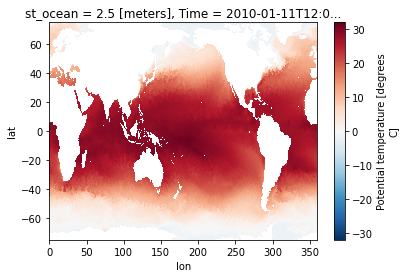

In [28]:
G_BRANt = G_BRAN.assign_coords(lon=(['xt_ocean'],G_BRAN.xt_ocean.values),lat=(['yt_ocean'],G_BRAN.yt_ocean.values))
G_BRANt = G_BRANt.swap_dims({'xt_ocean':'lon','yt_ocean':'lat'})
G_BRANt_lon,G_BRANt_lat = np.meshgrid(G_BRANt.lon.values,G_BRANt.lat.values)
G_BRANt = G_BRANt.assign(lon_t=(['lat','lon'],G_BRANt_lon),lat_t=(['lat','lon'],G_BRANt_lat))
tocn    = xr.open_dataset(os.path.join(D_BRAN,'temp','ocean_temp_2010_01.nc'))
sst     = tocn.sel(st_ocean=0,method='nearest')
sst     = sst.assign_coords(lon=(['xt_ocean'],sst.xt_ocean.values),lat=(['yt_ocean'],sst.yt_ocean.values))
sst     = sst.swap_dims({'xt_ocean':'lon','yt_ocean':'lat'})
sst.isel(Time=10).temp.plot()
print(sst)

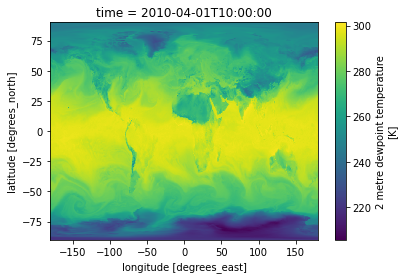

In [11]:
t2d = xr.open_dataset(os.path.join(D_ERA5,'2d','2010','2d_era5_oper_sfc_20100401-20100430.nc'))
ERA5_lon,ERA5_lat = np.meshgrid(G_BRANt.lon.values,G_BRANt.lat.values)
t2d.isel(time=10).d2m.plot()

Text(0.5, 1.0, 'ERA5 grid')

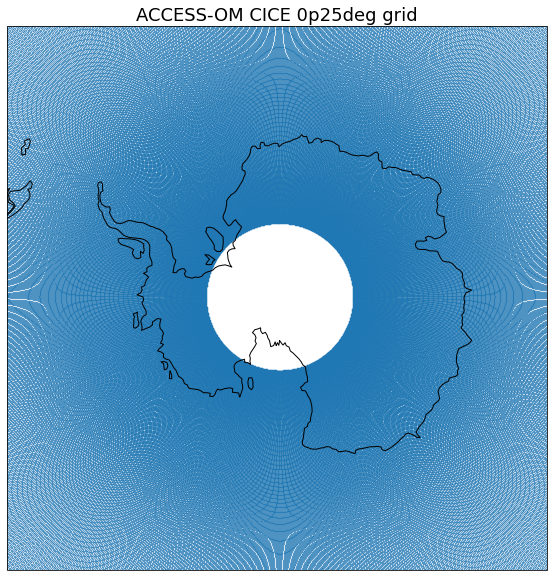

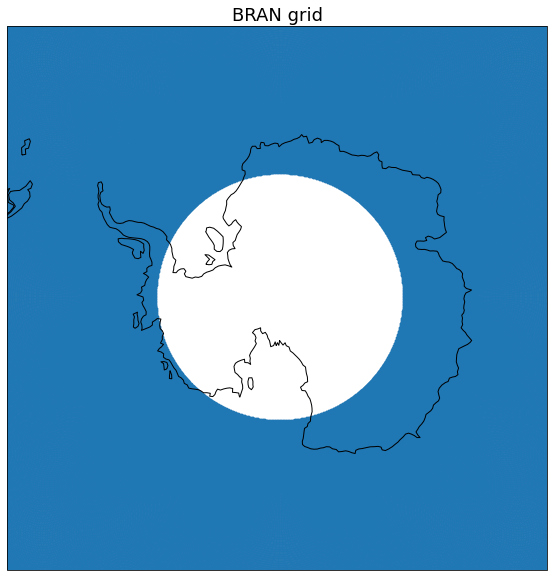

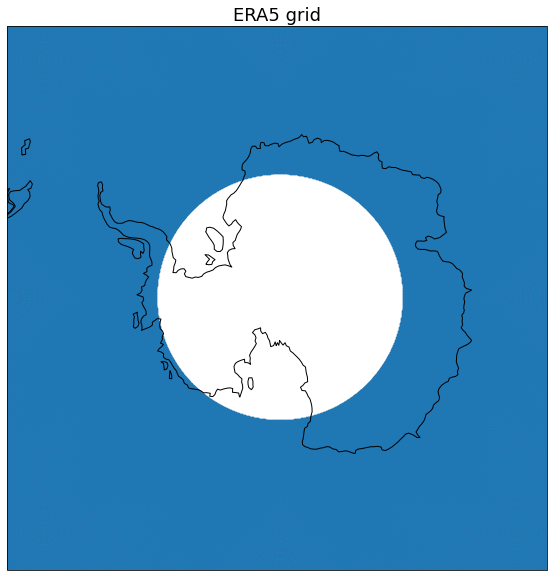

In [25]:
plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.cartopy.crs.Orthographic(central_longitude=0.0, central_latitude=-90))
ax.coastlines()
ax.scatter(G025t['lon_t'], G025t['lat_t'], s=0.1, transform=data_crs)  # plot grid locations
ax.set_extent([-180, 180, -55, -90], crs=ccrs.PlateCarree())
plt.title('ACCESS-OM CICE 0p25deg grid', fontsize=18)

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.cartopy.crs.Orthographic(central_longitude=0.0, central_latitude=-90))
ax.coastlines()
ax.scatter(G_BRANt['lon_t'], G_BRANt['lat_t'], s=0.1, transform=data_crs)  # plot grid locations
ax.set_extent([-180, 180, -55, -90], crs=ccrs.PlateCarree())
plt.title('BRAN grid', fontsize=18)

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.cartopy.crs.Orthographic(central_longitude=0.0, central_latitude=-90))
ax.coastlines()
ax.scatter(ERA5_lon, ERA5_lat, s=0.1, transform=data_crs)  # plot grid locations
ax.set_extent([-180, 180, -55, -90], crs=ccrs.PlateCarree())
plt.title('ERA5 grid', fontsize=18)

In [29]:
reG_BRANtoOM = xe.Regridder(sst, G025t, 'bilinear', periodic=True,
                            filename=os.path.join(D02,'model_input','grids','0p25','xesmf_weights_BRANtoOM.nc'))

ValueError: ESMC_FieldRegridStore failed with rc = 545. Please check the log files (named "*ESMF_LogFile").

In [19]:
reG_ERA5toOM = xe.Regridder(t2d, G025t, 'bilinear', periodic=True,
                            filename=os.path.join(D02,'model_input','grids','0p25','xesmf_weights_ERA5toOM.nc'))

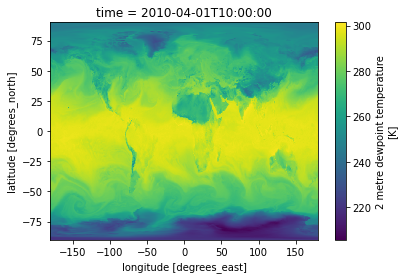

In [24]:
t2d.d2m.isel(time=10).plot()

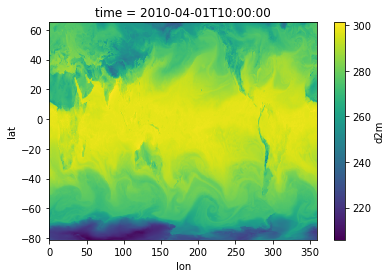

In [23]:
t2d_reG = reG_ERA5toOM(t2d)
t2d_reG.d2m.isel(time=10).plot()